In [ ]:
# Task 2 visualization

In [101]:
#Import packages
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Settings
random_state = 42

In [102]:
# Load the data 
adata = sc.read_h5ad("../data/frangieh/adata_qc_done.h5ad")

In [103]:
# Separate the data into three datasets regarding each condition
adata_control = adata[adata.obs["condition"] == "Control"].copy()
adata_ifng = adata[adata.obs["condition"] == "IFNγ"].copy()
adata_coculture = adata[adata.obs["condition"] == "Co-culture"].copy()

In [104]:
# Normalize the dataset adata_control 
sc.pp.normalize_total(adata_control, target_sum=1e4)
# Logarithmize the data
sc.pp.log1p(adata_control)

In [105]:
# Normalize the dataset adata_ifng 
sc.pp.normalize_total(adata_ifng, target_sum=1e4)
# Logarithmize the data
sc.pp.log1p(adata_ifng)

In [106]:
# Normalize the dataset adata_coculture
sc.pp.normalize_total(adata_coculture, target_sum = 1e4)
sc.pp.log1p(adata_coculture)

In [107]:
# Compute HVG
sc.pp.highly_variable_genes(adata_control, n_top_genes=2000)
sc.pp.highly_variable_genes(adata_ifng, n_top_genes=2000)
sc.pp.highly_variable_genes(adata_coculture, n_top_genes=2000)

In [108]:
# Save HVG-filtered datasets
adata_control_hvg = adata_control[:, adata_control.var["highly_variable"]].copy()
adata_ifng_hvg = adata_ifng[:, adata_ifng.var["highly_variable"]].copy()
adata_coculture_hvg = adata_coculture[:, adata_coculture.var["highly_variable"]].copy()
#Print the shape of the data
print(adata_control_hvg.shape)
print(adata_ifng_hvg.shape)
print(adata_coculture_hvg.shape)

(49895, 2000)
(74186, 2000)
(67093, 2000)


In [109]:
# Compute LFC
import anndata as ad
def compute_pseudobulk_lfc(
    adata: ad.AnnData,
    cond_key: str = "perturbation_2",
    pert_key: str = "perturbation",
    control_label: str = "control",
    min_cells: int = 15,
    pseudocount: float = 1.0,
    data_type: str = "log1p",
) -> ad.AnnData:

    """
    Compute pseudobulk log2 fold-change profiles for each perturbation
    relative to control cells within each experimental condition.

    Each output observation represents one perturbation in one condition.
    """

    # -------------------------------------------------------
    # 1. Copy and clean metadata
    # -------------------------------------------------------

    obs_df = adata.obs.copy()

    obs_df[pert_key] = (
        obs_df[pert_key]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    ctrl_label_clean = str(control_label).strip().lower()


    # -------------------------------------------------------
    # 2. Keep perturbations with at least min_cells overall
    # -------------------------------------------------------

    if min_cells > 0:

        dataset_counts = obs_df[pert_key].value_counts()

        valid_perts = dataset_counts[
            dataset_counts >= min_cells
        ].index

        cell_mask = obs_df[pert_key].isin(valid_perts).values

        adata_filtered = adata[cell_mask].copy()
        obs_df = obs_df.loc[cell_mask].copy()

    else:

        adata_filtered = adata.copy()


    # -------------------------------------------------------
    # 3. Convert expression back to linear scale if needed
    # -------------------------------------------------------

    if data_type == "log1p":

        if issparse(adata_filtered.X):

            X_linear = adata_filtered.X.copy().astype(np.float64)

            X_linear.data = np.expm1(X_linear.data)

            X_linear.data = np.nan_to_num(
                X_linear.data,
                nan=0.0,
                posinf=0.0,
                neginf=0.0
            )

            X_linear.data[X_linear.data < 0] = 0.0
            X_linear.eliminate_zeros()

        else:

            X_linear = np.expm1(
                np.asarray(
                    adata_filtered.X,
                    dtype=np.float64
                )
            )

            X_linear = np.nan_to_num(
                X_linear,
                nan=0.0,
                posinf=0.0,
                neginf=0.0
            )

            X_linear[X_linear < 0] = 0.0


    elif data_type == "counts":

        if issparse(adata_filtered.X):

            X_linear = adata_filtered.X.copy().astype(np.float64)

            X_linear.data = np.nan_to_num(
                X_linear.data,
                nan=0.0,
                posinf=0.0,
                neginf=0.0
            )

            X_linear.data[X_linear.data < 0] = 0.0
            X_linear.eliminate_zeros()

        else:

            X_linear = np.asarray(
                adata_filtered.X,
                dtype=np.float64
            )

            X_linear = np.nan_to_num(
                X_linear,
                nan=0.0,
                posinf=0.0,
                neginf=0.0
            )

            X_linear[X_linear < 0] = 0.0

    else:
        raise ValueError(
            "data_type must be either 'counts' or 'log1p'"
        )


    # -------------------------------------------------------
    # 4. Compute condition-specific perturbation LFC profiles
    # -------------------------------------------------------

    lfc_matrices = []
    obs_metadata_list = []


    for cond_val, cond_obs in obs_df.groupby(cond_key):

        cond_indices = cond_obs.index

        cond_mask = obs_df.index.isin(cond_indices)

        X_cond = X_linear[cond_mask, :]

        cond_perts = (
            obs_df.loc[cond_indices, pert_key]
            .values
        )

        pert_counts_in_cond = (
            cond_obs[pert_key]
            .value_counts()
        )


        # Control cells for this condition
        ctrl_mask = cond_perts == ctrl_label_clean

        if not np.any(ctrl_mask):

            print(
                f"Skipping {cond_val}: "
                f"no '{ctrl_label_clean}' control cells found."
            )

            continue


        # Mean control expression
        if issparse(X_cond):

            ctrl_mean = np.asarray(
                X_cond[ctrl_mask, :].mean(axis=0)
            ).ravel()

        else:

            ctrl_mean = X_cond[
                ctrl_mask, :
            ].mean(axis=0)


        # Non-control perturbations
        target_perts = [
            p
            for p in np.unique(cond_perts)
            if p != ctrl_label_clean
        ]


        cond_lfc_list = []
        retained_obs = []


        for pert in target_perts:

            p_mask = cond_perts == pert


            # Optional condition-specific min-cell check
            if p_mask.sum() < min_cells:
                continue


            if issparse(X_cond):

                p_mean = np.asarray(
                    X_cond[p_mask, :].mean(axis=0)
                ).ravel()

            else:

                p_mean = X_cond[
                    p_mask, :
                ].mean(axis=0)


            # log2 fold-change
            lfc = np.log2(
                (p_mean + pseudocount) /
                (ctrl_mean + pseudocount)
            )

            cond_lfc_list.append(lfc)


            retained_obs.append({
                cond_key: cond_val,
                pert_key: pert,
                "n_cells_pseudobulk": int(p_mask.sum())
            })


        if len(cond_lfc_list) > 0:

            lfc_matrices.append(
                np.vstack(cond_lfc_list)
            )

            obs_metadata_list.extend(
                retained_obs
            )


    # -------------------------------------------------------
    # 5. Build final perturbation-level AnnData
    # -------------------------------------------------------

    if not lfc_matrices:

        raise ValueError(
            "No valid perturbation groups were found."
        )


    final_lfc_matrix = np.vstack(
        lfc_matrices
    )


    final_obs_df = pd.DataFrame(
        obs_metadata_list
    )


    final_obs_df.index = [
        f"{row[cond_key]}_{row[pert_key]}"
        for row in obs_metadata_list
    ]


    lfc_adata = ad.AnnData(
        X=final_lfc_matrix,
        obs=final_obs_df,
        var=adata_filtered.var.copy()
    )


    lfc_adata.uns["lfc_baseline_label"] = control_label
    lfc_adata.uns["pseudocount"] = pseudocount


    return lfc_adata

In [110]:
sc.pp.normalize_total(adata, target_sum = 1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes =2000)

In [111]:
adata_hvg = adata[:, adata.var["highly_variable"]].copy()

In [262]:
lfc_adata_control_hvg = compute_pseudobulk_lfc(
    adata=adata_control_hvg,
    cond_key="condition",
    pert_key="perturbation",
    control_label="control",
    min_cells=15,
    pseudocount=1.0,
    data_type="log1p"
)

lfc_adata_ifng_hvg = compute_pseudobulk_lfc(
    adata=adata_ifng_hvg,
    cond_key="condition",
    pert_key="perturbation",
    control_label="control",
    min_cells=15,
    pseudocount=1.0,
    data_type="log1p"
)

lfc_adata_coculture_hvg = compute_pseudobulk_lfc(
    adata=adata_coculture_hvg,
    cond_key="condition",
    pert_key="perturbation",
    control_label="control",
    min_cells=15,
    pseudocount=1.0,
    data_type="log1p"
)

/tmp/ipykernel_30716/1267067442.py:145: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for cond_val, cond_obs in obs_df.groupby(cond_key):
/tmp/ipykernel_30716/1267067442.py:145: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for cond_val, cond_obs in obs_df.groupby(cond_key):
/tmp/ipykernel_30716/1267067442.py:145: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for cond_val, cond_obs in obs_df.groupby(cond_key):


In [277]:
sc.tl.pca(lfc_adata_control_hvg, n_comps=30)
sc.tl.pca(lfc_adata_ifng_hvg, n_comps=30)
sc.tl.pca(lfc_adata_coculture_hvg, n_comps=30)

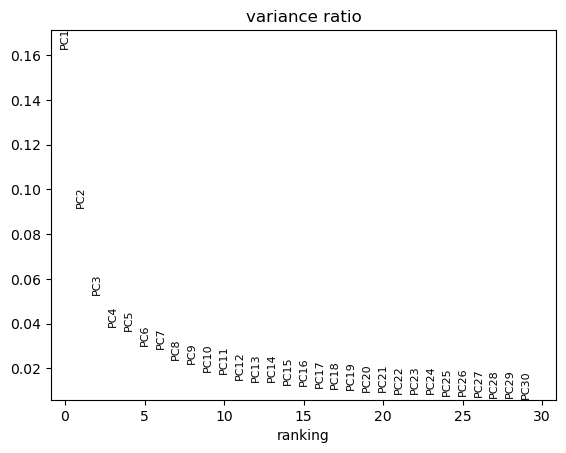

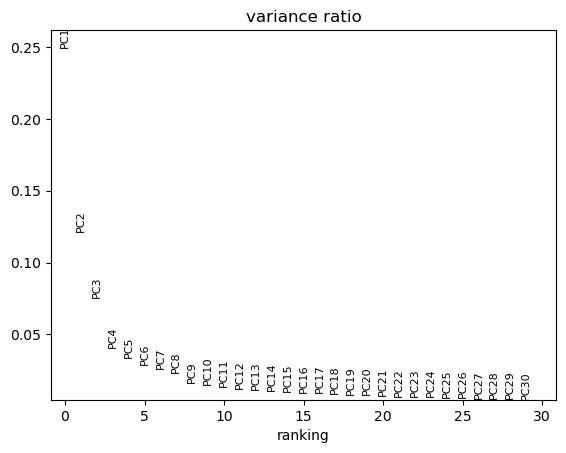

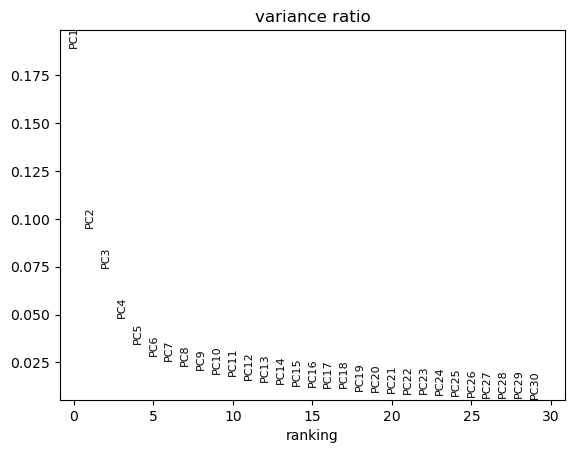

In [279]:
sc.pl.pca_variance_ratio(lfc_adata_control_hvg, n_pcs=30, log=False)
sc.pl.pca_variance_ratio(lfc_adata_coculture_hvg, n_pcs=30, log=False)
sc.pl.pca_variance_ratio(lfc_adata_ifng_hvg, n_pcs = 30, log =False)

In [310]:
def find_optimal_k_hierarchical(
    adata,
    condition,
    max_k=10,
    n_pcs=15
):

    X = adata.obsm["X_pca"][:, :n_pcs]

    scores = []
    k_values = range(2, max_k + 1)

    for k in k_values:
        model = AgglomerativeClustering(
            n_clusters=k,
            linkage="ward"
        )

        labels = model.fit_predict(X)
        scores.append(silhouette_score(X, labels))

    best_k = np.argmax(scores) + 2

    print(f"{condition}: optimal hierarchical k = {best_k}")

    plt.figure(figsize=(6, 4))
    plt.plot(k_values, scores, marker="o")
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Silhouette score")
    plt.title(f"{condition} – Hierarchical Clustering")
    plt.show()

    return best_k

Control: optimal hierarchical k = 2


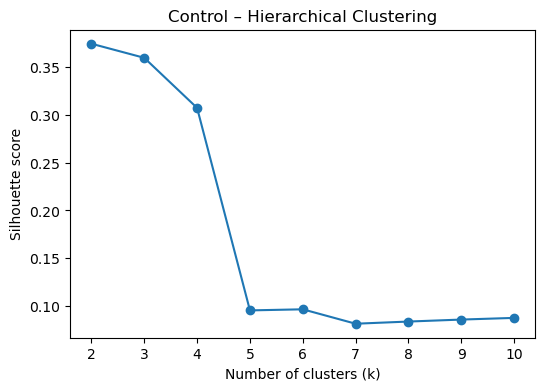

IFNγ: optimal hierarchical k = 2


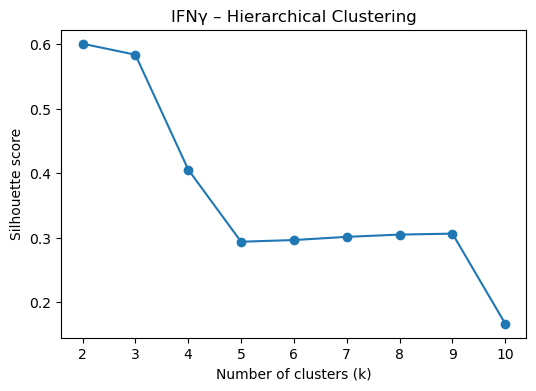

Co-culture: optimal hierarchical k = 3


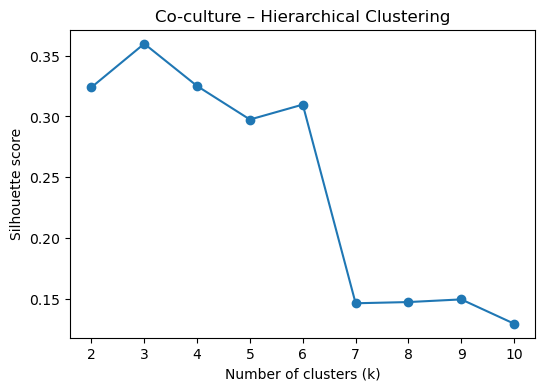

In [311]:
k_hier_control = find_optimal_k_hierarchical(
    lfc_adata_control_hvg,
    "Control"
)

k_hier_ifng = find_optimal_k_hierarchical(
    lfc_adata_ifng_hvg,
    "IFNγ"
)

k_hier_coculture = find_optimal_k_hierarchical(
    lfc_adata_coculture_hvg,
    "Co-culture"
)

In [312]:
from sklearn.cluster import AgglomerativeClustering

datasets = [
    (lfc_adata_control_hvg, 2),
    (lfc_adata_ifng_hvg, 2),
    (lfc_adata_coculture_hvg, 3)
]

for obj, k in datasets:
    X = obj.obsm["X_pca"][:, :15]

    model = AgglomerativeClustering(
        n_clusters=k,
        metric="euclidean",
        linkage="ward"
    )

    obj.obs["hierarchical"] = model.fit_predict(X).astype(str)

In [313]:
for obj in [
    lfc_adata_control_hvg,
    lfc_adata_ifng_hvg,
    lfc_adata_coculture_hvg
]:
    sc.pp.neighbors(
        obj,
        use_rep="X_pca",
        n_pcs=15
    )

    sc.tl.leiden(
        obj,
        resolution=0.5,
        key_added="leiden",
        flavor="igraph",
        n_iterations=2
    )

In [314]:
def get_high_lfc_genes(obj):

    X = obj.X

    if hasattr(X, "toarray"):
        X = X.toarray()

    max_abs_lfc = np.max(np.abs(X), axis=1)

    threshold = np.percentile(max_abs_lfc, 90)

    genes = (
        obj.obs.loc[
            max_abs_lfc >= threshold,
            "perturbation"
        ]
        .astype(str)
        .str.upper()
        .tolist()
    )

    return genes, threshold


genes_to_label_LFC_control, threshold_control = \
    get_high_lfc_genes(lfc_adata_control_hvg)

genes_to_label_LFC_ifng, threshold_ifng = \
    get_high_lfc_genes(lfc_adata_ifng_hvg)

genes_to_label_LFC_coculture, threshold_coculture = \
    get_high_lfc_genes(lfc_adata_coculture_hvg)

In [315]:
genes_to_label = [
    "STAT1",
    "JAK1",
    "JAK2",
    "IFNGR1",
    "IFNGR2"
]

In [316]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# ============================================================
# 1. Find optimal k for K-means using the first 15 PCs
# ============================================================

def find_optimal_k(adata, max_k=10, n_pcs=15):
    
    X = adata.obsm["X_pca"][:, :n_pcs]
    
    max_k = min(max_k, X.shape[0] - 1)
    k_values = range(2, max_k + 1)
    
    silhouette_scores = []
    
    for k in k_values:
        model = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=20
        )
        
        labels = model.fit_predict(X)
        score = silhouette_score(X, labels)
        silhouette_scores.append(score)
    
    best_k = list(k_values)[np.argmax(silhouette_scores)]
    
    print(
        f"Optimal k = {best_k}, "
        f"silhouette = {max(silhouette_scores):.3f}"
    )
    
    return best_k


# Find optimal k separately for each condition

k_control = find_optimal_k(lfc_adata_control_hvg)
k_ifng = find_optimal_k(lfc_adata_ifng_hvg)
k_coculture = find_optimal_k(lfc_adata_coculture_hvg)

Optimal k = 2, silhouette = 0.372
Optimal k = 3, silhouette = 0.563
Optimal k = 3, silhouette = 0.379


In [317]:
# For 15 PCs k optimal is control 2
#ifng 3
#coculture 3
k_control = 2
k_ifng = 3
k_coculture = 3

In [318]:
def run_kmeans(adata, k, n_pcs=15):
    
    X = adata.obsm["X_pca"][:, :n_pcs]
    
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    adata.obs["kmeans"] = (
        model.fit_predict(X)
        .astype(str)
    )


run_kmeans(
    lfc_adata_control_hvg,
    k_control
)

run_kmeans(
    lfc_adata_ifng_hvg,
    k_ifng
)

run_kmeans(
    lfc_adata_coculture_hvg,
    k_coculture
)

In [319]:
print("Control threshold:", threshold_control)
print("IFNγ threshold:", threshold_ifng)
print("Co-culture threshold:", threshold_coculture)

Control threshold: 2.0340320368933096
IFNγ threshold: 1.9645102789951168
Co-culture threshold: 1.9984321725051357


In [320]:
import os
import matplotlib.pyplot as plt
import scanpy as sc


def plot_high_lfc(
    adata,
    condition,
    clustering_method,
    high_lfc_genes
):
    
    X_pca = adata.obsm["X_pca"]
    
    # Smaller figure
    fig, ax = plt.subplots(
        figsize=(9, 7)
    )
    
    # Larger dots
    sc.pl.pca(
        adata,
        color=clustering_method,
        ax=ax,
        show=False,
        size=200
    )
    
    high_lfc_set = set(
        gene.upper()
        for gene in high_lfc_genes
    )
    
    for i, pert in enumerate(
        adata.obs["perturbation"]
    ):
        
        pert_upper = str(pert).upper()
        
        if pert_upper in high_lfc_set or pert_upper in genes_to_label:
            
            ax.annotate(
                pert_upper,
                (
                    X_pca[i, 0],
                    X_pca[i, 1]
                ),
                xytext=(6, 6),
                textcoords="offset points",
                fontsize=9,
                fontweight="bold"
            )
    
    
    method_titles = {
        "kmeans": "K-means",
        "hierarchical": "Hierarchical",
        "leiden": "Leiden"
    }
    
    method_title = method_titles[
        clustering_method
    ]
    
    ax.set_title(
        f"{condition} – {method_title} Clustering in PCA Space",
        fontsize=16
    )
    
    ax.set_xlabel(
        "PC1",
        fontsize=13
    )
    
    ax.set_ylabel(
        "PC2",
        fontsize=13
    )
    
    plt.tight_layout()
    
    
    safe_condition = (
        condition
        .replace("γ", "G")
        .replace("-", "")
    )
    
    filename = (
        f"{safe_condition}_"
        f"{method_title.replace('-', '')}_"
        f"highLFC.png"
    )
    
    # Create results folder if it does not exist
    output_dir = "results_task2"
    os.makedirs(output_dir, exist_ok=True)
    
    # Full output path
    output_path = os.path.join(
        output_dir,
        filename
    )
    
    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )
    
    plt.show()

In [334]:
import os
import matplotlib.pyplot as plt
import scanpy as sc
from adjustText import adjust_text


def plot_high_lfc(
    adata,
    condition,
    clustering_method,
    high_lfc_genes
):
    
    X_pca = adata.obsm["X_pca"]

    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot PCA
    sc.pl.pca(
        adata,
        color=clustering_method,
        ax=ax,
        show=False,
        size=180,
        legend_loc="right margin"
    )

    # High-LFC genes only
    high_lfc_set = {
        gene.upper()
        for gene in high_lfc_genes
    }

    texts = []

    for i, pert in enumerate(adata.obs["perturbation"]):

        pert_upper = str(pert).upper()

        # Label only high-LFC genes
        if pert_upper in high_lfc_set:

            text = ax.text(
                X_pca[i, 0],
                X_pca[i, 1],
                pert_upper,
                fontsize=9,
                fontweight="bold"
            )

            texts.append(text)

    # Separate overlapping labels
    adjust_text(
        texts,
        ax=ax,
        arrowprops=dict(
            arrowstyle="-",
            linewidth=0.7
        )
    )

    method_titles = {
        "kmeans": "K-means",
        "hierarchical": "Hierarchical",
        "leiden": "Leiden"
    }

    method_title = method_titles[clustering_method]

    ax.set_title(
        f"{condition} – {method_title}",
        fontsize=15
    )

    ax.set_xlabel("PC1", fontsize=12)
    ax.set_ylabel("PC2", fontsize=12)

    plt.tight_layout()

    # Save directory
    output_dir = "results_task2"
    os.makedirs(output_dir, exist_ok=True)

    safe_condition = (
        condition
        .replace("γ", "G")
        .replace("-", "")
    )

    filename = (
        f"{safe_condition}_"
        f"{method_title.replace('-', '')}_"
        f"highLFC.png"
    )

    output_path = os.path.join(
        output_dir,
        filename
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

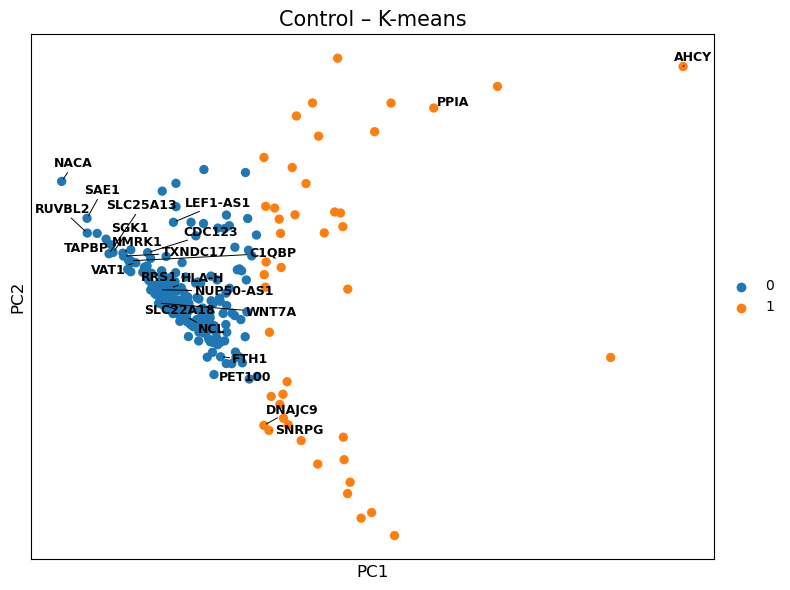

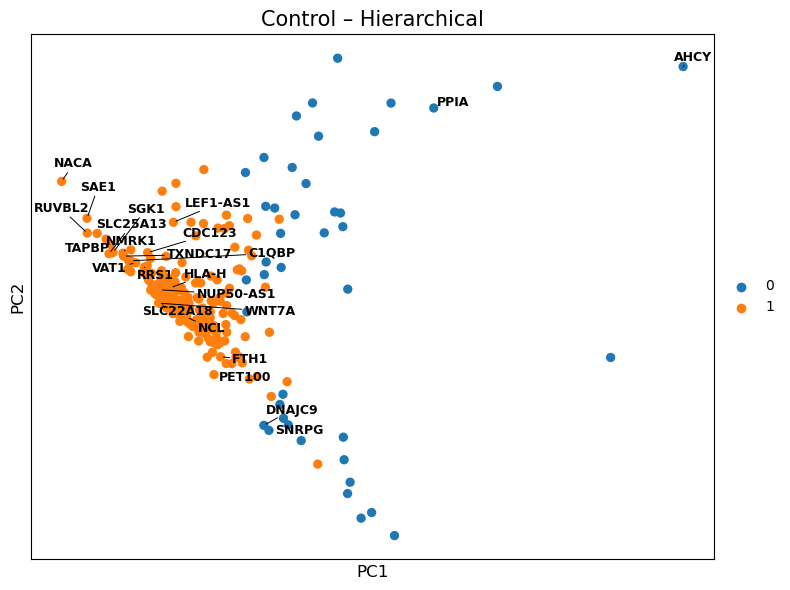

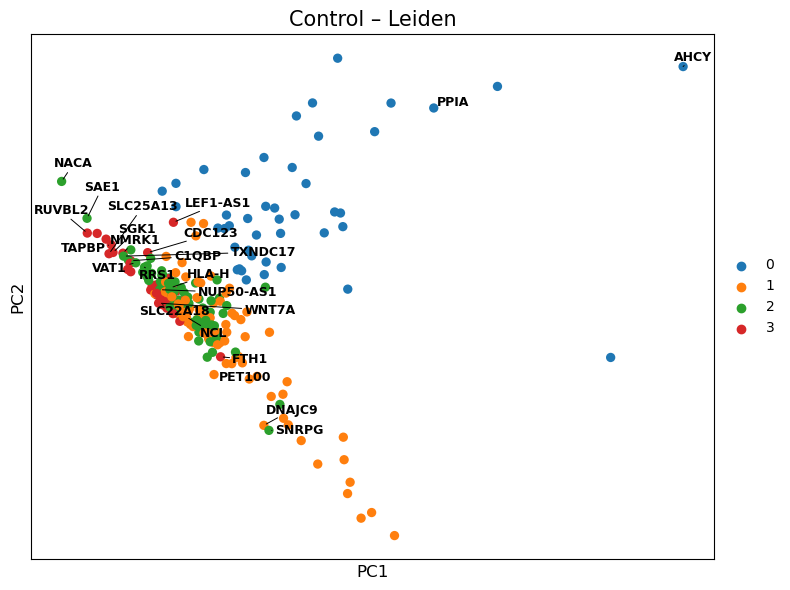

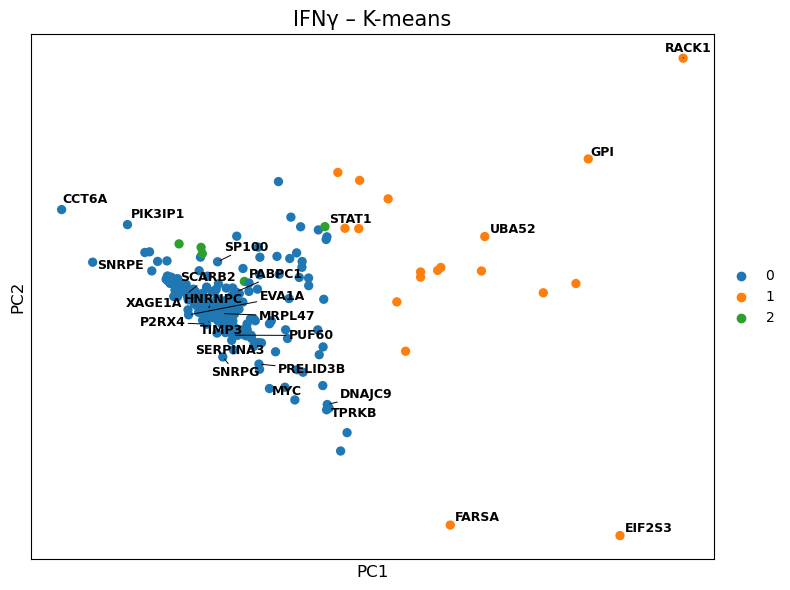

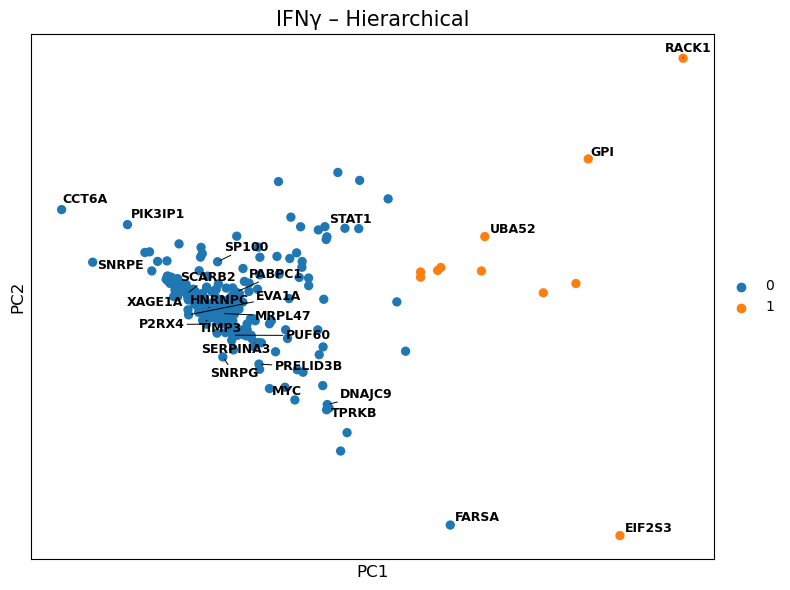

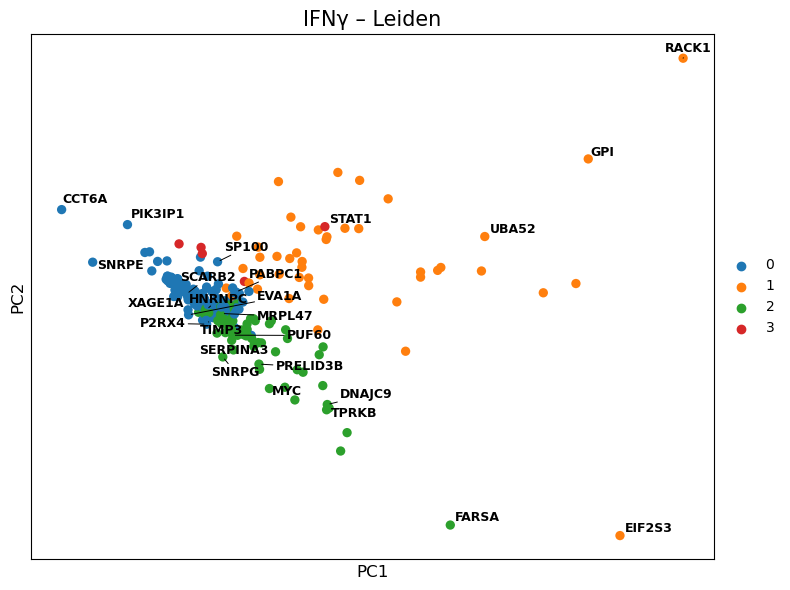

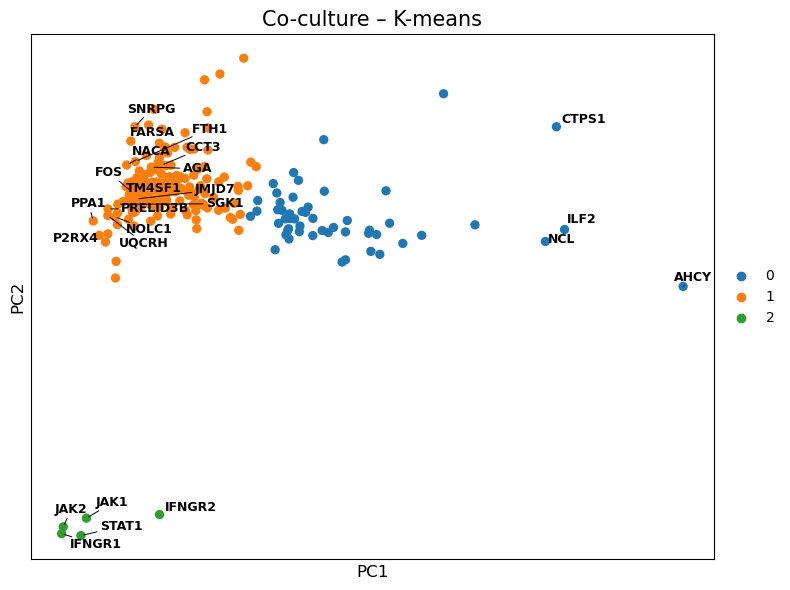

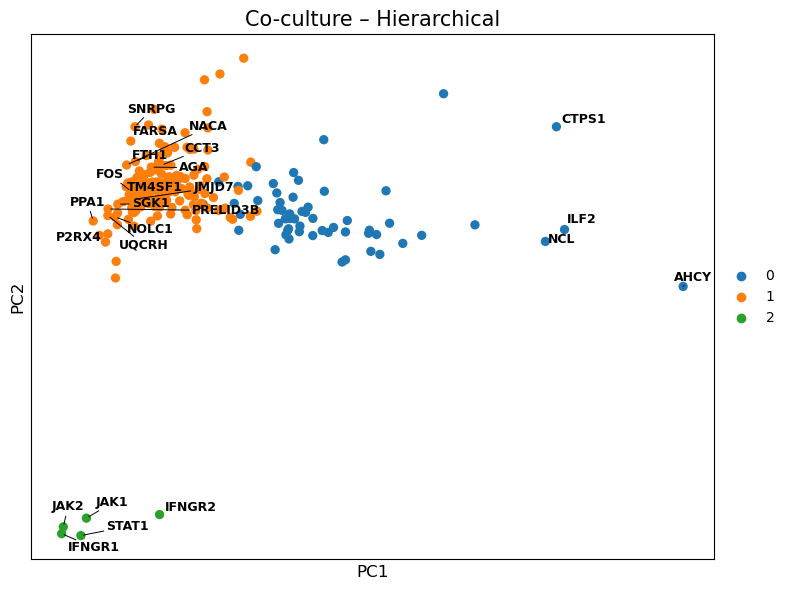

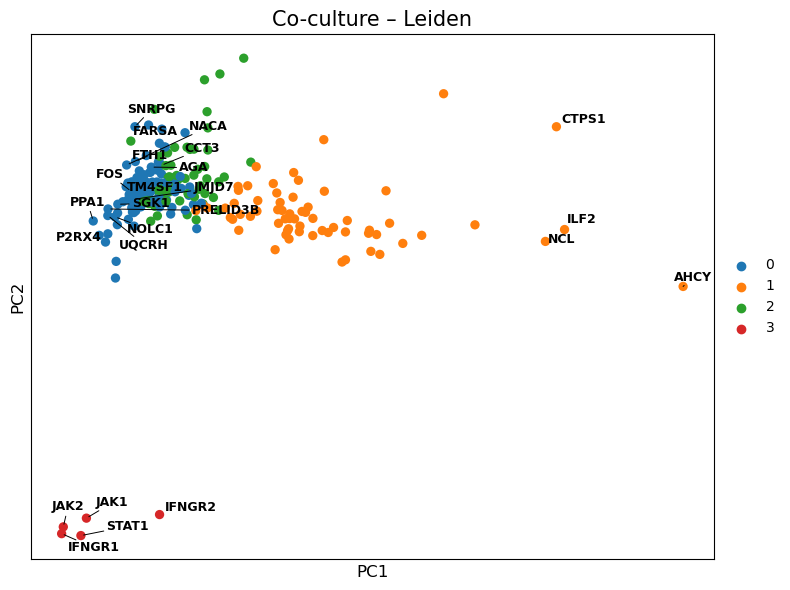

In [335]:
conditions = {
    "Control": (
        lfc_adata_control_hvg,
        genes_to_label_LFC_control
    ),
    
    "IFNγ": (
        lfc_adata_ifng_hvg,
        genes_to_label_LFC_ifng
    ),
    
    "Co-culture": (
        lfc_adata_coculture_hvg,
        genes_to_label_LFC_coculture
    )
}


methods = [
    "kmeans",
    "hierarchical",
    "leiden"
]


for condition, (adata_obj, high_lfc_genes) in conditions.items():
    
    for method in methods:
        
        plot_high_lfc(
            adata=adata_obj,
            condition=condition,
            clustering_method=method,
            high_lfc_genes=high_lfc_genes
        )